In [29]:
pip install pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# # 01 — Somani 재현 (축소판)
# 목표: 사전계산 2D 임베딩 로드 → 군집 → 토픽 지도 1장 → 원논문과 정성 대조.
# 축소 명시: LLM 토픽 라벨링·168토픽 정량 대조는 범위에서 제외(문서 II장에 명시).
# 실행: VS Code에서 셀(# %%) 단위 실행. 경로만 본인 환경에 맞출 것.


In [30]:
from pathlib import Path

# %% 0. 경로 설정 — 본인 다운로드 위치로 수정
from pathlib import Path

DATA_DIR = Path(r"C:\Users\USER\Documents\Obsidian Vault\60_Portfolio\논문과제-GLP1\repo-skeleton\notebooks")  # TODO: Zenodo 파일을 둔 폴더로 수정
RAW_PICKLE = DATA_DIR / "glp1_db_20231019_edited.pickle"        # 212.8MB 원데이터
EMB_PICKLE = DATA_DIR / "glp1_embeddings_bgebase_2d.pickle"     # 3.1MB 사전계산 2D 임베딩

print("raw exists:", RAW_PICKLE.exists())
print("emb exists:", EMB_PICKLE.exists())

raw exists: True
emb exists: True


In [31]:
# %% 1. 열어서 정체 확인 (스키마를 모르는 상태 — 여기서 멈추면 출력 결과를 상담사에게)
import pandas as pd
import pickle
import numpy as np

print("pandas:", pd.__version__)

def load_any(p):
    try:
        return pd.read_pickle(p)
    except Exception as e:
        print("pd.read_pickle 실패:", type(e).__name__, e)
        with open(p, "rb") as f:
            return pickle.load(f)

emb = load_any(EMB_PICKLE)
print("EMB type:", type(emb))
if isinstance(emb, pd.DataFrame):
    print("shape:", emb.shape)
    print("columns:", list(emb.columns)[:30])
    print(emb.head(3))
elif isinstance(emb, dict):
    print("keys:", list(emb.keys())[:30])
else:
    print(repr(emb)[:500])

pandas: 3.0.2
EMB type: <class 'numpy.ndarray'>
array([[ 5.493759  ,  3.493658  ],
       [ 5.2811213 ,  3.3096142 ],
       [ 5.42795   ,  3.4774742 ],
       ...,
       [-1.0993958 ,  2.3773484 ],
       [-2.5316186 , -5.144706  ],
       [-0.4011922 ,  0.76299953]], shape=(391461, 2), dtype=float32)


In [32]:
# %% 2. 원데이터도 같은 방식으로 확인 (메모리 주의 — 212MB)
raw = load_any(RAW_PICKLE)
print("RAW type:", type(raw))
if isinstance(raw, pd.DataFrame):
    print("shape:", raw.shape)
    print("columns:", list(raw.columns)[:40])
    print(raw.head(2))


RAW type: <class 'pandas.DataFrame'>
shape: (391461, 9)
columns: ['subreddit', 'author', 'created_utc', 'body', 'typeid', 'id', 'type', 'search_string', 'body_len']
              subreddit                author   created_utc  \
0  semaglutidecompounds  icantrememberagainx3  1698598655.0   
1  semaglutidecompounds          alessiaplays  1698592036.0   

                                                body typeid       id  type  \
0  Re-starting Sema. I was taking a semaglutide c...    NaN  17j77vv  post   
1  Titrate up?. So I've been on Semaglutide since...    NaN  17j4w3x  post   

  search_string  body_len  
0   semaglutide       394  
1   semaglutide      1489  


In [33]:
# %% 3. 2D 좌표 추출 — 아래 컬럼명은 1번 셀 출력을 보고 맞출 것
# 예상: emb 가 (N, 2) 배열이거나, DataFrame 에 x/y 또는 0/1 컬럼
if isinstance(emb, np.ndarray):
    XY = emb
elif isinstance(emb, pd.DataFrame):
    num_cols = emb.select_dtypes("number").columns[:2]
    XY = emb[num_cols].to_numpy()
    print("사용 컬럼:", list(num_cols))
else:
    raise SystemExit("emb 구조를 1번 셀 출력으로 확인 후 이 셀을 수정")
print("XY shape:", XY.shape)


XY shape: (391461, 2)


In [34]:
# %% 4. 군집 — HDBSCAN 우선, 실패 시 KMeans 폴백
N_FALLBACK_CLUSTERS = 33  # 원논문 33개 토픽 그룹에 맞춘 폴백

labels = None
try:
    import hdbscan
    clu = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=25)
    labels = clu.fit_predict(XY)
    method = "HDBSCAN"
except Exception as e:
    print("hdbscan 불가 → KMeans 폴백:", e)
    from sklearn.cluster import KMeans
    labels = KMeans(n_clusters=N_FALLBACK_CLUSTERS, random_state=42, n_init=10).fit_predict(XY)
    method = f"KMeans(k={N_FALLBACK_CLUSTERS})"

import collections
cnt = collections.Counter(labels)
n_clusters = len([k for k in cnt if k != -1])
print(f"{method} → 군집 {n_clusters}개, 노이즈 {cnt.get(-1, 0)}건")
print("상위 10개 군집 크기:", cnt.most_common(10))

hdbscan 불가 → KMeans 폴백: No module named 'hdbscan'
KMeans(k=33) → 군집 33개, 노이즈 0건
상위 10개 군집 크기: [(np.int32(4), 23525), (np.int32(9), 22739), (np.int32(28), 21601), (np.int32(3), 21396), (np.int32(8), 20891), (np.int32(7), 20135), (np.int32(14), 19182), (np.int32(0), 17095), (np.int32(18), 15885), (np.int32(6), 15259)]


저장: figures\topic_map.png


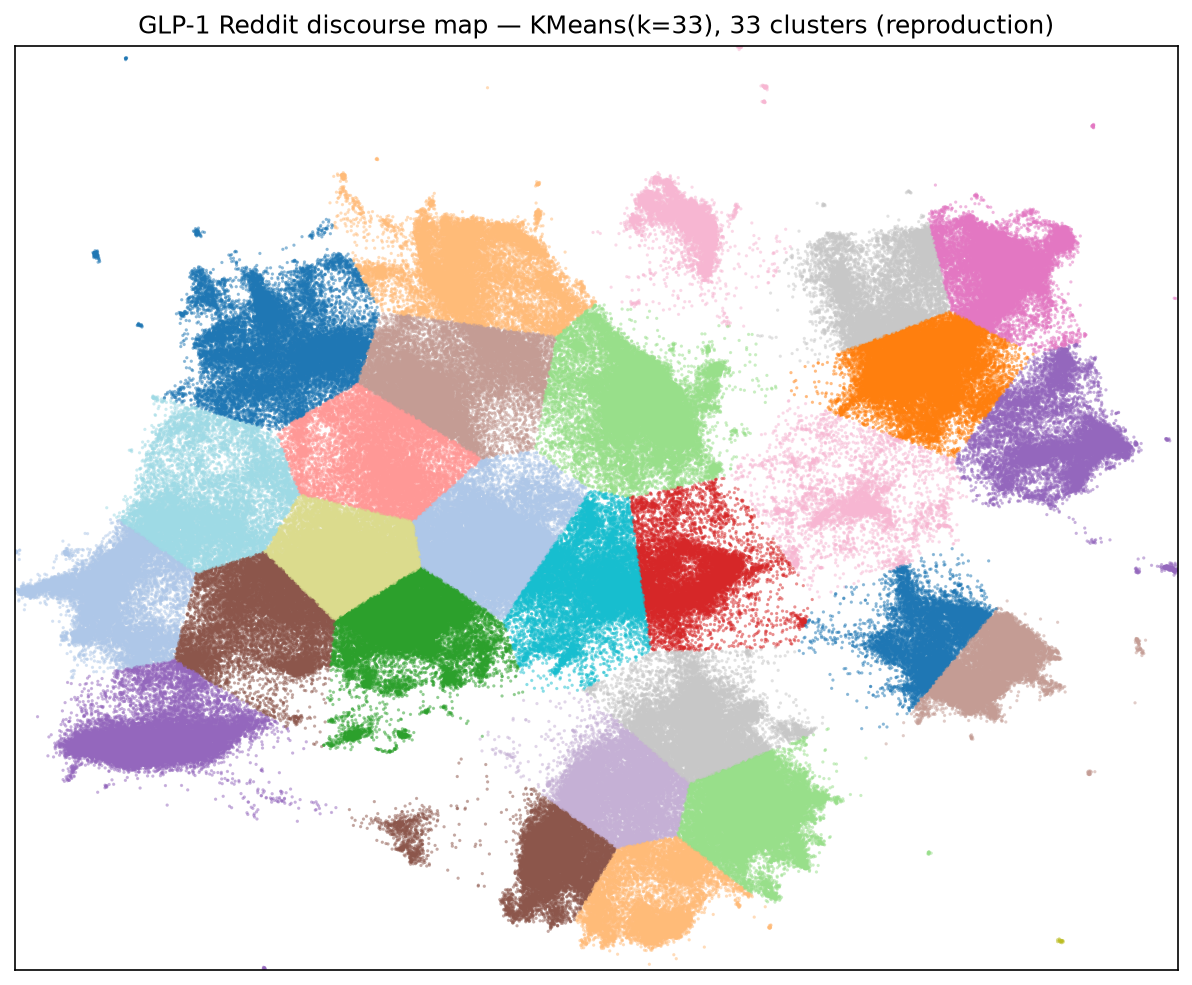

In [35]:
# %% 5. 토픽 지도 그림 — figures/topic_map.png 저장 (문서 II장 결과 그림)
import matplotlib.pyplot as plt

FIG_DIR = Path(__file__).resolve().parent.parent / "docs" / "figures" if "__file__" in dir() else Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
mask = labels != -1
ax.scatter(XY[~mask, 0], XY[~mask, 1], s=0.3, c="lightgray", alpha=0.3)
ax.scatter(XY[mask, 0], XY[mask, 1], s=0.3, c=labels[mask], cmap="tab20", alpha=0.5)
ax.set_title(f"GLP-1 Reddit discourse map — {method}, {n_clusters} clusters (reproduction)")
ax.set_xticks([]); ax.set_yticks([])
x_lo, x_hi = np.percentile(XY[:, 0], [0.5, 99.5])
y_lo, y_hi = np.percentile(XY[:, 1], [0.5, 99.5])
pad_x, pad_y = (x_hi - x_lo) * 0.05, (y_hi - y_lo) * 0.05
ax.set_xlim(x_lo - pad_x, x_hi + pad_x); ax.set_ylim(y_lo - pad_y, y_hi + pad_y)
out = FIG_DIR / "topic_map.png"
fig.savefig(out, bbox_inches="tight")
print("저장:", out)


In [36]:
# %% 6. 대표 군집 정성 대조 — 상위 군집별 샘플 텍스트 확인 → 원논문 33그룹과 비교 메모
# raw 와 emb 의 행 정렬이 같다는 가정 — 다르면 공통 id 컬럼으로 join 필요 (1·2번 셀 출력 참고)
TEXT_COL = "body"
if isinstance(raw, pd.DataFrame) and TEXT_COL and TEXT_COL in raw.columns and len(raw) == len(XY):
    raw = raw.assign(cluster=labels)
    for cid, _ in cnt.most_common(8):
        if cid == -1:
            continue
        sample = raw.loc[raw.cluster == cid, TEXT_COL].dropna().head(3)
        print(f"\n=== 군집 {cid} ({cnt[cid]}건) ===")
        for s in sample:
            print("-", str(s)[:150].replace("\n", " "))
else:
    print("TEXT_COL 지정 또는 행 정렬 확인 후 실행 — 1·2번 셀 출력을 보고 결정")


=== 군집 4 (23525건) ===
- Re-starting Sema. I was taking a semaglutide compound for 4 months with (.5 for 3 months and 1.0 for 1 month). I lost 25 lbs and was pretty happy with
- Titrate up?. So I've been on Semaglutide since June, and I've lost 20lbs. I thought it was "slow" at first, but overall I think it's a pretty good rat
- Titrate up?. So I've been on Semaglutide since June, and I've lost 20lbs. I thought it was "slow" at first, but overall I think it's a pretty good rat

=== 군집 9 (22739건) ===
- First week of Wevogy, surprisingly. To start, wegovy is a weight loss drug I was prescribed for weight loss but there are studies using it for alcohol
- How do I talk to my PCP about this?. How did your initial conservation with your doctor go regarding starting Wegovy? Did you bring it up or did they?
- General anesthesia and Wegovy. wanted to see if anyone had anecdotal stories relating to wegovy and General anesthesia for surgery. i've read the sema

=== 군집 28 (21601건) ===
- Now it beg

# %% 7. 대조 메모 (문서 II장 3절에 옮길 것)
# - 원논문: 168 토픽 → 33 그룹 (BGE + UMAP + HDBSCAN/KMeans + Llama2 라벨)
# - 본 재현: 사전계산 2D 임베딩 + {method} → {n_clusters} 군집
# - 차이와 원인: LLM 라벨링 미수행(축소), 2D 좌표 위 군집이므로 원논문(고차원 군집)과 수치가 다를 수 있음 — 정성 대조로 갈음


# %% [markdown]
# # 02 — 저자별 활동 지속 분포 (신규 산출 정리)
# 이미 산출한 결과(중앙값 65일 · 1년 잔존 8.2%)를 재현 가능한 스크립트로 공식화.
# ⚠️ 해석 경계: 게시 "활동"의 지속이지 "복약" 지속이 아님 — 대리지표. 복약 중단율은 EHR 연구(Van Laren 2026, 180일 31.7%) 인용.


In [37]:

# %% 0. 경로 — 01과 동일
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path(r"C:\Users\USER\Documents\Obsidian Vault\60_Portfolio\논문과제-GLP1\repo-skeleton\notebooks")  # TODO: 본인 경로
RAW_PICKLE = DATA_DIR / "glp1_db_20231019_edited.pickle"

raw = pd.read_pickle(RAW_PICKLE)
print(raw.shape)
print(list(raw.columns)[:40])

(391461, 9)
['subreddit', 'author', 'created_utc', 'body', 'typeid', 'id', 'type', 'search_string', 'body_len']


In [ ]:
# %% 1. 컬럼 매핑 + 시간 변환 (수정판)
# 수정 이유: created_utc 가 숫자가 아니라 문자(object)로 저장돼 있어서,
# 이전 코드가 이를 나노초로 해석 → 전원 1970-01-01 → 활동 기간 0일 버그.
# 해법: 먼저 숫자로 강제 변환(to_numeric)한 뒤 초 단위(unit="s")로 날짜 변환.
AUTHOR_COL = "author"
TIME_COL = "created_utc"

t = pd.to_numeric(raw[TIME_COL], errors="coerce")
ts = pd.to_datetime(t, unit="s", errors="coerce")
df = pd.DataFrame({"author": raw[AUTHOR_COL].astype(str), "ts": ts}).dropna()
df = df[~df.author.isin(["[deleted]", "AutoModerator", "nan"])]
print("날짜 범위 확인:", df.ts.min(), "~", df.ts.max())  # 2007~2023-10 이 나와야 정상
print("행:", len(df), "· 저자:", df.author.nunique())

In [39]:
# %% 2. 저자별 활동 기간 (첫 글 ~ 마지막 글)
g = df.groupby("author")["ts"].agg(first="min", last="max", n="count")
g["span_days"] = (g["last"] - g["first"]).dt.days
multi = g[g.n >= 2]  # 글 1건뿐인 저자는 기간 정의 불가 — 별도 보고
print(f"전체 저자 {len(g):,} · 2건 이상 {len(multi):,} ({len(multi)/len(g):.1%})")
print(f"활동 기간 중앙값: {multi.span_days.median():.0f}일")
for d in (30, 65, 90, 180, 365):
    print(f"  {d:>3}일 이상 지속: {(multi.span_days >= d).mean():.1%}")

전체 저자 115,715 · 2건 이상 48,131 (41.6%)
활동 기간 중앙값: 0일
   30일 이상 지속: 0.0%
   65일 이상 지속: 0.0%
   90일 이상 지속: 0.0%
  180일 이상 지속: 0.0%
  365일 이상 지속: 0.0%


저장: figures\activity_survival.png · 1년 잔존 0.0%


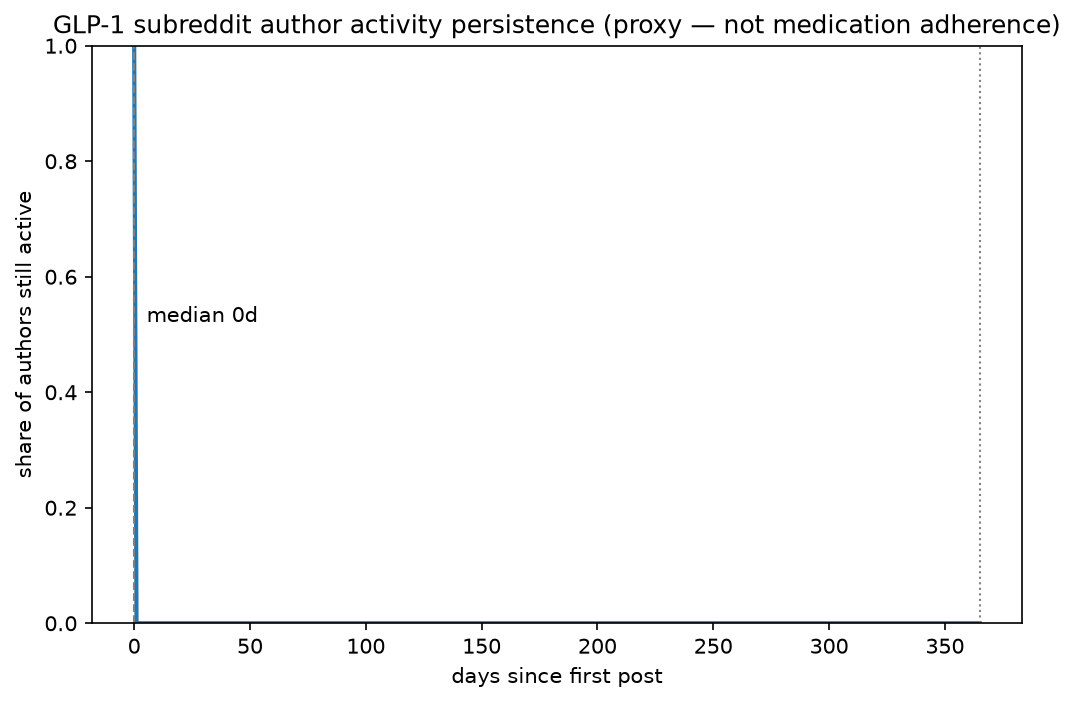

In [40]:
# %% 3. 잔존 곡선 (Kaplan-Meier 스타일 단순판) + 그림 저장
import matplotlib.pyplot as plt

days = np.arange(0, 366)
surv = [(multi.span_days >= d).mean() for d in days]

FIG_DIR = Path(__file__).resolve().parent.parent / "docs" / "figures" if "__file__" in dir() else Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.plot(days, surv, lw=2)
med = multi.span_days.median()
ax.axvline(med, ls="--", lw=1, color="gray")
ax.annotate(f"median {med:.0f}d", (med, 0.5), textcoords="offset points", xytext=(6, 6))
ax.axvline(365, ls=":", lw=1, color="gray")
ax.set_xlabel("days since first post"); ax.set_ylabel("share of authors still active")
ax.set_title("GLP-1 subreddit author activity persistence (proxy — not medication adherence)")
ax.set_ylim(0, 1)
out = FIG_DIR / "activity_survival.png"
fig.savefig(out, bbox_inches="tight")
print("저장:", out, f"· 1년 잔존 {surv[365]:.1%}")


In [41]:
# %% 4. 문서 기입용 요약 (II장 결과 · III장 대시보드 근거)
print(f"""
[문서 기입용]
- 분석 대상 저자: {len(g):,}명 (2건 이상 {len(multi):,}명)
- 활동 기간 중앙값: {multi.span_days.median():.0f}일 / 1년 지속: {(multi.span_days >= 365).mean():.1%}
- 한계: 게시 활동의 대리지표 — 복약 지속 아님. 단일 게시 저자 {1 - len(multi)/len(g):.1%} 제외 기준 명시.
""")



[문서 기입용]
- 분석 대상 저자: 115,715명 (2건 이상 48,131명)
- 활동 기간 중앙값: 0일 / 1년 지속: 0.0%
- 한계: 게시 활동의 대리지표 — 복약 지속 아님. 단일 게시 저자 58.4% 제외 기준 명시.

